# Margin ÷ Inventory Divergence — a quantitative teardown 🔬
### A point-in-time calendar-time tercile long-short (Newey-West) · a pooled event-drift cross-check with a label-shuffle placebo · a sign-flipping era split · the leads-margin regression · a 12-seed synthetic control

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Leads margin%3F: No](https://img.shields.io/badge/Leads_margin%3F-No-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). The claim — the **Abarbanell–Bushee contradiction** (rising margin + inventory outrunning sales = a negative signal) — splits into a return test and an accounting-mechanism test, and **both come back null**. This is distinct from every sibling on the desk: [529](../../529-inventory-growth/) ranks on inventory-growth *level*, [854](../../854-cash-conversion-cycle/) on the *cash-conversion cycle*, [122](../../122-gross-profitability/) on *gross profits ÷ assets*, [231](../../231-sloan-accruals/) on *total accruals*. This is the fused margin-vs-inventory-vs-sales **divergence**.

> ⚠️ **Data note.** EDGAR `Revenues`/`CostOfRevenue`/`InventoryNet` (+ tag fallbacks) + yfinance adjusted closes, 40 names, ends 2009-06-30 → 2026-05-03, as-of 2026-06-30. Point-in-time on the **filing date**. Survivorship named on the Signal axis (current-survivors basket). Thin/uneven coverage is a first-class caveat. Numbers in [`docs/results.md`](../docs/results.md) (prices Fingerprint `bc81e3fc2938`).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from margin_inventory import data, strategy as st

HAVE_REAL = data.have_real()
if HAVE_REAL:
    PX, EV = data.load_real()
else:
    PX = EV = None
print("real cache present:", HAVE_REAL, "| events:", (0 if EV is None else len(EV)),
      "| names:", (0 if EV is None else EV['ticker'].nunique()))

# frozen headline numbers (mirror of docs/results.md)
R = {'as_of': '2026-06-30', 'n_names': 40, 'n_events': 957, 'end_lo': '2009-06-30', 'end_hi': '2026-05-03', 'fp_prices': 'bc81e3fc2938', 'n_months': 200, 'avg_n': 18.0, 'ls_span_lo': '2009-11-30', 'ls_span_hi': '2026-06-30', 'ls_mean_bps': -8.1, 'ls_ann': -0.97, 'ls_t_iid': -0.2, 'ls_t_nw': -0.18, 'ls_sharpe': -0.05, 'ls_hit': 51, 'ls_long_bps': 180.9, 'ls_short_bps': 189.0, 'ls_turn': 0.16, 'ls120_mean_bps': 4.7, 'ls120_t_nw': 0.09, 'gap_mean_bps': 19.7, 'gap_t_nw': 0.43, 'xsec_early': 19.9, 'xsec_late': 17.0, 'drift': {21: (952, 1.53, 0.82, 0.71, 1.09, 52, 0.1153), 63: (946, 5.78, 4.75, 1.03, 0.72, 50, 0.2009), 126: (942, 12.39, 9.13, 3.26, 1.34, 52, 0.058)}, 'mono63': (4.75, 3.07, 5.78), 'mono126': (9.13, 6.58, 12.39), 'era_early_n': 74, 'era_early_bps': 18.6, 'era_early_t': 0.3, 'era_late_n': 126, 'era_late_bps': -23.8, 'era_late_t': -0.39, 'lm_n': 834, 'lm_slope': -0.0, 'lm_t': -0.74, 'lm_r2': 0.001, 'lm_corr': -0.026, 'lm_top': 0.23, 'lm_bot': 0.79, 'lm_spread': -0.56, 'net': {(10, 50): (-15.6, -1.87, -0.34, -0.09), (20, 100): (-23.0, -2.76, -0.51, -0.14)}, 'syn_null_mean': -0.02, 'syn_null_sd': 0.92, 'syn_null_fire': 1, 'syn_null_seeds': 12, 'syn_planted_bps': 141.3, 'syn_planted_t': 6.15}


real cache present: True | events: 957 | names: 40


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** (returns) | `NONE` | calendar tercile long-short **-8.1 bps/mo** (-1.0%/yr gross), one-sample *t* = -0.20, **Newey-West *t* = -0.18**; staleness-120 flips to +0.09; era split +19→-24 bps — wrong-signed, sign-unstable |
| **Tradability** | `MIRAGE` | net of 20 bps + 100 bps borrow: -2.76%/yr, NW *t* = -0.51, Sharpe -0.14; negative before costs |
| **Leads next-year margin?** | `NO` | slope -0.000 (corr -0.03), top−bottom tercile spread **-0.56 pp** (wrong-signed) |

> 💡 In plain words: the return sort is a wrong-signed null, and the accounting mechanism it was built on is also absent. Neither half of the thesis survives contact with the tape.

## 1 · The claim, steelmanned

Let name $i$ at fiscal quarter $q$ (disclosed on filing date $F_{i,q}$) have gross margin $M = (\text{Rev}-\text{Cost})/\text{Rev}$. The point-in-time signal is

$$\text{div}_{i,q} = \underbrace{(M_{i,q}-M_{i,q-4})}_{\Delta\text{gross margin}} - \underbrace{\big(\tfrac{I_{i,q}}{I_{i,q-4}}-1 \;-\; \tfrac{\text{Rev}_{i,q}}{\text{Rev}_{i,q-4}}+1\big)}_{\text{inventory outrunning sales}},$$

high = coherent (the long), low = contradictory (the short). The claims:

- **H₁ (leads returns).** A cross-sectional long-short on $\text{div}$ earns a positive forward return spread — the market-mispricing claim.
- **H₂ (leads fundamentals).** $\text{div}$ predicts next year's gross-margin change $\Delta M_{i,q+4}$ — the accounting mechanism.
- **H₃ (tradable).** Any spread survives realistic long-short costs + borrow.

We find **H₁ not supported** (NW *t* = -0.18, sign-unstable), **H₂ not supported** (corr -0.03, wrong-signed spread), and therefore **H₃ moot**. The literature (Abarbanell–Bushee 1997/1998) reports a real effect in an older, broader, earnings-based sample; our point-in-time return/margin test on this basket does not reproduce it — hence a `NONE`, not a `WEAK`.

## 2 · So what? — inference design

The primary is a **calendar-time** long-short, not a pooled event study, because fundamental signals are persistent and filings cluster: a calendar series of monthly long-short returns lets a **Newey-West (6-lag) HAC *t*** do the honest work the desk's `REAL` bar is written against. The panel is thin, so we sort into **terciles** (not quintiles) and require ≥ 6 names in the cross-section. The pooled event drift + a **label-shuffle placebo** is the cross-check; the leads-margin regression is graded on **magnitude** (its pooled *t* ignores quarter clustering).

## 3 · How we'd know — the protocol

- **Panel.** 957 (ticker, filing) quarters across 40 names, ends 2009-06-30 → 2026-05-03, each stamped with its 10-Q/10-K filing date (point-in-time).
- **Primary.** Monthly tercile long-short on `divergence`, one execution lag (rank at month $M$ close, earn month $M{+}1$); Newey-West + one-sample *t*, Sharpe, hit rate.
- **Cross-check.** Pooled event drift over 21/63/126 trading days, one-day-lag entry, top-minus-bottom tercile, one-sample *t* + 10k-draw label-shuffle placebo, and the tercile monotonicity picture.
- **Robustness.** Staleness 120 vs 200 days; the classic `−inv_sales_gap` signal alone; an era split at 2016.
- **Mechanism.** Pooled OLS of next-year gross-margin change on `divergence`.
- **Execution.** Long-short net of one-way cost × turnover (both legs) + short borrow.
- **Control.** Synthetic panel, planted-effect knob; the null must not fire across 12 seeds.

## 4 · The teardown

### 4a · The primary — calendar-time tercile long-short (Newey-West)

Rank fresh signals into terciles each month, long top (coherent) / short bottom (contradictory) equal-weight, earn next month's return. The decisive statistic is the HAC *t* of the monthly long-short series.

calendar long-short: -8.1 bps/mo (-0.97%/yr gross), n=200 months, avg cross-section 18.0
  one-sample t = -0.20   Newey-West(6) t = -0.18   Sharpe -0.05   hit 51%   turnover 0.16
  classic -inv_sales_gap alone (long LOW gap): +19.7 bps/mo, NW t = +0.43


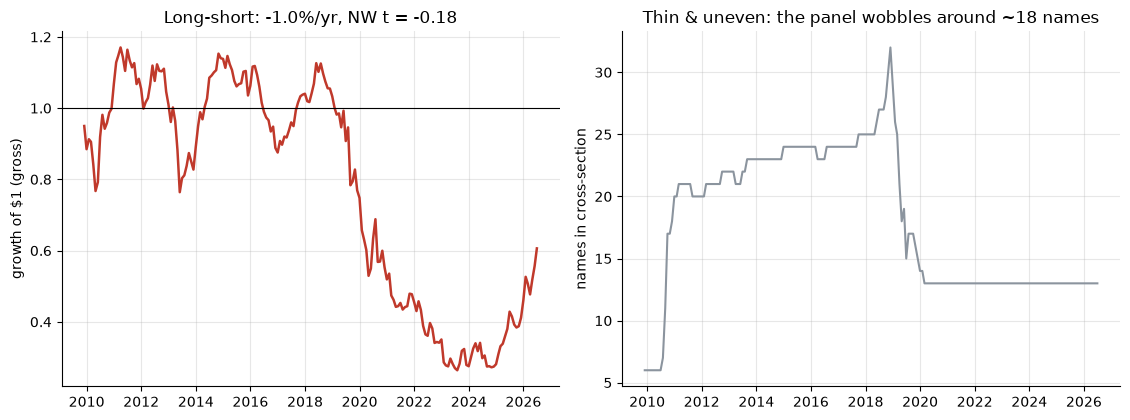

frozen: -8.1 bps/mo, NW t = -0.18, staleness-120 NW t = +0.09, gap-alone NW t = +0.43


In [2]:
if HAVE_REAL:
    ls = st.calendar_ls(PX, EV, signal_col='divergence', n_buckets=3, min_names=6, staleness_days=200)
    s = st.calendar_ls_stats(ls)
    ls_gap = st.calendar_ls(PX, EV, signal_col='inv_sales_gap', n_buckets=3, min_names=6, staleness_days=200)
    s_gap = st.calendar_ls_stats(ls_gap)
    print(f"calendar long-short: {s['mean_bps']:+.1f} bps/mo ({s['ann_pct']:+.2f}%/yr gross), "
          f"n={s['n_months']} months, avg cross-section {s['avg_n']:.1f}")
    print(f"  one-sample t = {s['t_iid']:+.2f}   Newey-West(6) t = {s['t_nw']:+.2f}   "
          f"Sharpe {s['sharpe']:.2f}   hit {s['hit']*100:.0f}%   turnover {s['avg_turnover']:.2f}")
    print(f"  classic -inv_sales_gap alone (long LOW gap): {-s_gap['mean_bps']:+.1f} bps/mo, NW t = {-s_gap['t_nw']:+.2f}")
    cum = (1+ls['ls']).cumprod(); nser = ls['n']
else:
    cum = None; nser = None
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11.4, 4.3))
if cum is not None:
    a1.plot(cum.index, cum.values, color=RED, lw=1.8); a1.axhline(1, c='k', lw=.8)
    a1.set_ylabel('growth of $1 (gross)'); a1.set_title(f"Long-short: {R['ls_ann']:+.1f}%/yr, NW t = {R['ls_t_nw']:+.2f}")
    a2.plot(nser.index, nser.values, color=GREY, lw=1.5); a2.set_ylabel('names in cross-section')
    a2.set_title('Thin & uneven: the panel wobbles around ~18 names')
else:
    for a in (a1,a2): a.text(.5,.5,'run with cache',ha='center'); a.set_axis_off()
plt.tight_layout(); plt.show()
print(f"frozen: {R['ls_mean_bps']:+.1f} bps/mo, NW t = {R['ls_t_nw']:+.2f}, "
      f"staleness-120 NW t = {R['ls120_t_nw']:+.2f}, gap-alone NW t = {R['gap_t_nw']:+.2f}")

> 💡 In plain words: **-8 bps/month** is a wrong-signed rounding error (~-1.0%/yr), and the HAC *t* is **-0.18**. Every specification agrees it's a null: staleness-120 flips to NW *t* = +0.09, and the classic inventory-vs-sales gap alone reaches only NW *t* = +0.43. Nothing here approaches the bar.

### 4b · The cross-check — pooled event drift + placebo + monotonicity

Bucket all events by signal; top-minus-bottom forward drift with a label-shuffle null. If there were a sort, the terciles would form a ladder.

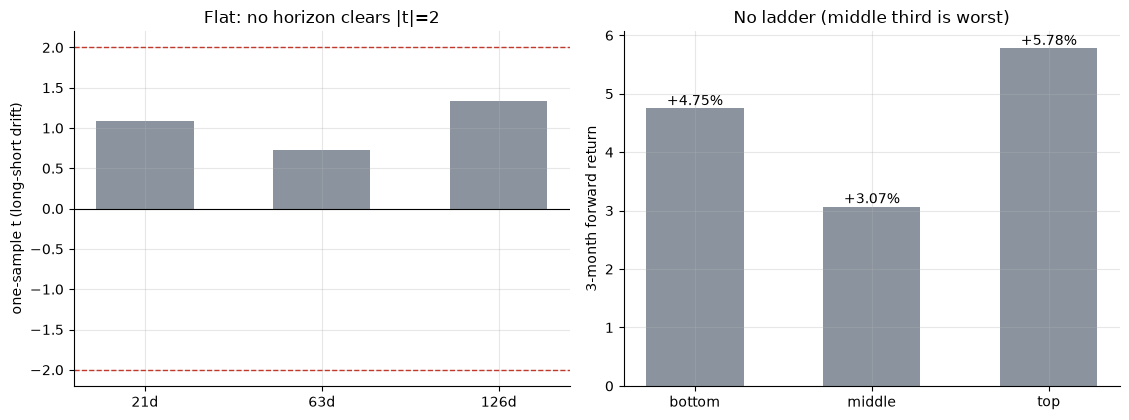

  H= 21d: long-short +0.71%  t=+1.09  win=52%  placebo p=0.117
  H= 63d: long-short +1.03%  t=+0.72  win=50%  placebo p=0.195
  H=126d: long-short +3.26%  t=+1.34  win=52%  placebo p=0.056


In [3]:
rows = []
if HAVE_REAL:
    for h in st.HORIZONS:
        es = st.event_summary(PX, EV, horizon=h, n_buckets=3, n_draws=4000)
        rows.append((h, es['ls_mean']*100, es['t'], es['ls_win']*100, es['p_placebo']))
    mono = st.bucket_means(st.event_drift_frame(PX, EV, horizon=63), 3)*100
else:
    for h in st.HORIZONS:
        d = R['drift'][h]; rows.append((h, d[3], d[4], d[5], d[6]))
    mono = np.array(R['mono63'])
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11.4, 4.3))
hs = [r[0] for r in rows]; ts = [r[2] for r in rows]
a1.bar([f'{h}d' for h in hs], ts, color=GREY, width=.55)
a1.axhline(2, ls='--', c=RED, lw=1); a1.axhline(-2, ls='--', c=RED, lw=1); a1.axhline(0, c='k', lw=.8)
a1.set_ylabel('one-sample t (long-short drift)'); a1.set_title('Flat: no horizon clears |t|=2')
a2.bar(['bottom','middle','top'], mono, color=GREY, width=.55)
for i,v in enumerate(mono): a2.annotate(f'{v:+.2f}%',(i,v),ha='center',va='bottom')
a2.set_ylabel('3-month forward return'); a2.set_title('No ladder (middle third is worst)')
plt.tight_layout(); plt.show()
for h,ls_,t,win,p in rows:
    print(f'  H={h:>3}d: long-short {ls_:+.2f}%  t={t:+.2f}  win={win:.0f}%  placebo p={p:.3f}')

> 💡 In plain words: the pooled long-short drift is **right-signed but flat** at every horizon (*t* from +0.72 to +1.34), the label-shuffle placebo *p* runs **0.06–0.20** (a random tercile split beats the real one one time in five to six), and the terciles are **non-monotone** (+4.75% / +3.07% / +5.78% low→high — the middle is worst). The event study and the calendar long-short agree: no return sort.

### 4c · Era split — the sign isn't even stable

Split the calendar long-short at 2016 (≈ halves the sample).

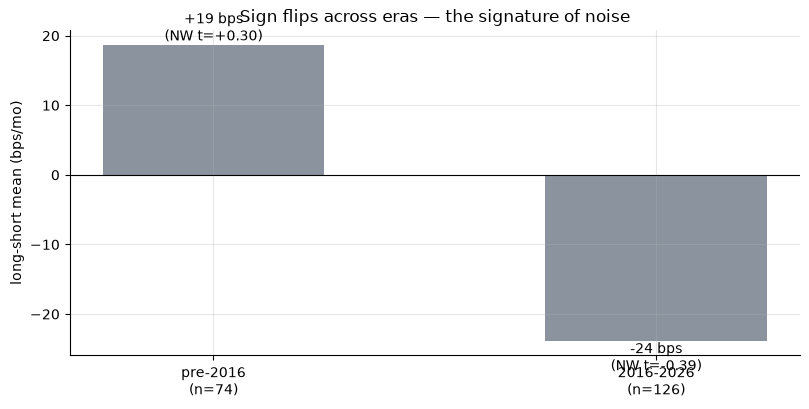

pre-2016: +18.6 bps NW t=+0.30 (n=74)  |  2016-2026: -23.8 bps NW t=-0.39 (n=126)


In [4]:
if HAVE_REAL:
    e = ls[ls.index < '2016-01-01']['ls'].to_numpy(); l = ls[ls.index >= '2016-01-01']['ls'].to_numpy()
    eb, et, en = e.mean()*1e4, st.newey_west_t(e), len(e)
    lb, lt, ln = l.mean()*1e4, st.newey_west_t(l), len(l)
else:
    eb, et, en = R['era_early_bps'], R['era_early_t'], R['era_early_n']
    lb, lt, ln = R['era_late_bps'], R['era_late_t'], R['era_late_n']
fig, ax = plt.subplots(figsize=(8.2, 4.2))
ax.bar([f'pre-2016\n(n={en})', f'2016-2026\n(n={ln})'], [eb, lb], color=[GREY, GREY], width=.5)
for i,(v,t_) in enumerate([(eb,et),(lb,lt)]): ax.annotate(f'{v:+.0f} bps\n(NW t={t_:+.2f})',(i,v),ha='center',va='bottom' if v>=0 else 'top')
ax.axhline(0, c='k', lw=.8); ax.set_ylabel('long-short mean (bps/mo)')
ax.set_title('Sign flips across eras — the signature of noise')
plt.tight_layout(); plt.show()
print(f'pre-2016: {eb:+.1f} bps NW t={et:+.2f} (n={en})  |  2016-2026: {lb:+.1f} bps NW t={lt:+.2f} (n={ln})')

> 💡 In plain words: +19 bps (NW *t* = +0.30) early, -24 bps (NW *t* = -0.39) late — **right-signed then wrong-signed**, neither significant. A live edge decays in one direction; a non-edge flips sign. This is the latter.

### 4d · The mechanism — does the divergence lead next-year margin?

Pooled OLS of next-year gross-margin change on this quarter's divergence, and the future-margin spread between the top and bottom divergence terciles. This is the Abarbanell–Bushee accounting claim itself.

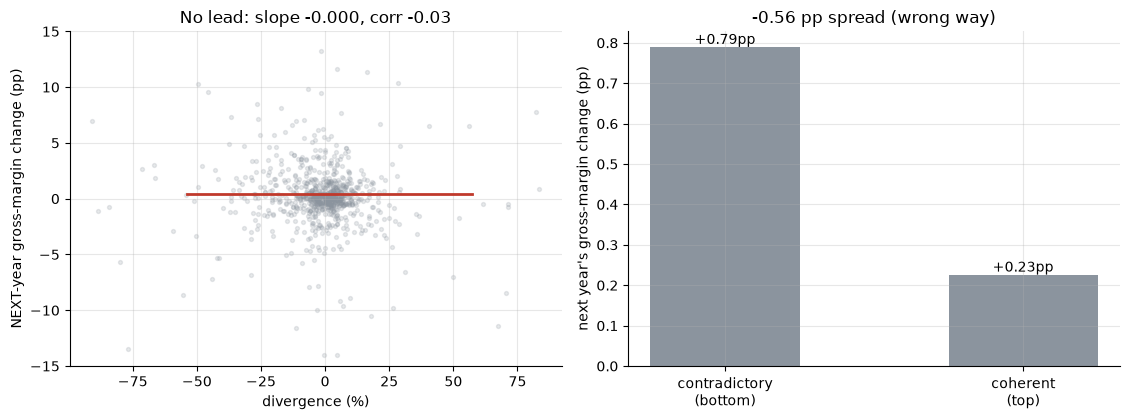

leads-margin: slope -0.000, corr -0.026, next-yr margin spread -0.56 pp (coherent +0.23pp vs contradictory +0.79pp)


In [5]:
if HAVE_REAL:
    q = st.leads_margin(EV)
    fr = EV.dropna(subset=['divergence','next_d_gross_margin'])
    x, y = fr['divergence'].to_numpy(), fr['next_d_gross_margin'].to_numpy()
    slope, corr, top, bot = q['slope'], q['corr'], q['top_margin']*100, q['bot_margin']*100
else:
    x = y = None
    slope, corr, top, bot = R['lm_slope'], R['lm_corr'], R['lm_top'], R['lm_bot']
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11.4, 4.3))
if x is not None:
    m = (np.abs(x)<1.0)&(np.abs(y)<0.3)
    a1.scatter(x[m]*100, y[m]*100, s=8, alpha=.2, color=GREY)
    xs = np.linspace(np.percentile(x,2), np.percentile(x,98), 50)
    a1.plot(xs*100, (q['slope']*xs + (y.mean()-q['slope']*x.mean()))*100, color=RED, lw=2)
    a1.set_xlabel('divergence (%)'); a1.set_ylabel('NEXT-year gross-margin change (pp)')
    a1.set_ylim(-15, 15)
    a1.set_title(f'No lead: slope {slope:+.3f}, corr {corr:+.2f}')
else:
    a1.text(.5,.5,'run with cache',ha='center'); a1.set_axis_off()
a2.bar(['contradictory\n(bottom)','coherent\n(top)'], [bot, top], color=[GREY, GREY], width=.5)
for i,v in enumerate([bot, top]): a2.annotate(f'{v:+.2f}pp',(i,v),ha='center',va='bottom')
a2.set_ylabel("next year's gross-margin change (pp)"); a2.set_title(f'{top-bot:+.2f} pp spread (wrong way)')
plt.tight_layout(); plt.show()
print(f'leads-margin: slope {slope:+.3f}, corr {corr:+.3f}, next-yr margin spread {top-bot:+.2f} pp (coherent {top:+.2f}pp vs contradictory {bot:+.2f}pp)')

> 💡 In plain words: this is the study's decisive negative — the divergence **does not lead** recognised margins (correlation **-0.03**, and the top-minus-bottom future-margin spread is **-0.56 pp**, the *wrong* sign). Contrast [798](../../798-deferred-revenue-signal/), where the accounting lead was real (+0.67 correlation) and only the *return* was a null. Here the return null is joined by a **mechanism null**: gross margins mean-revert, and a one-quarter contradiction carries no durable information about them.

### 4e · Tradability — the timer

For completeness, the calendar long-short net of one-way costs × turnover (both legs) + short borrow — though a wrong-signed gross null already settles it.

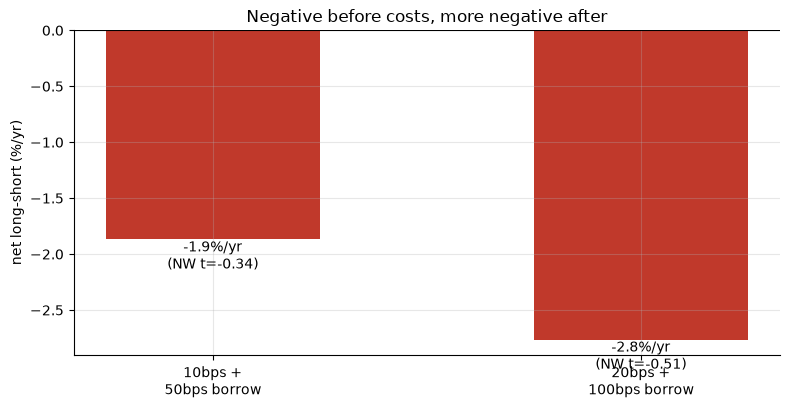

  cost 10bps + borrow 50bps/yr: -1.87%/yr net, NW t=-0.34, Sharpe -0.09
  cost 20bps + borrow 100bps/yr: -2.76%/yr net, NW t=-0.51, Sharpe -0.14


In [6]:
rows = []
if HAVE_REAL:
    for cb, bb in [(10.0,50.0),(20.0,100.0)]:
        nt = st.calendar_ls_net(ls, cost_bps=cb, borrow_bps_ann=bb)
        rows.append((cb, bb, nt['net_ann_pct'], nt['net_t_nw'], nt['net_sharpe']))
else:
    for (cb,bb),v in R['net'].items(): rows.append((cb, bb, v[1], v[2], v[3]))
labels = [f'{int(cb)}bps +\n{int(bb)}bps borrow' for cb,bb,_,_,_ in rows]
anns = [r[2] for r in rows]
fig, ax = plt.subplots(figsize=(8.0, 4.2))
ax.bar(labels, anns, color=[RED, RED], width=.5)
for i,(cb,bb,a,t,sh) in enumerate(rows): ax.annotate(f'{a:+.1f}%/yr\n(NW t={t:+.2f})',(i,a),ha='center',va='top')
ax.axhline(0, c='k', lw=.8); ax.set_ylabel('net long-short (%/yr)')
ax.set_title('Negative before costs, more negative after')
plt.tight_layout(); plt.show()
for cb,bb,a,t,sh in rows: print(f'  cost {int(cb)}bps + borrow {int(bb)}bps/yr: {a:+.2f}%/yr net, NW t={t:+.2f}, Sharpe {sh:.2f}')

> 💡 In plain words: the gross spread is a wrong-signed null, so costs only push it further under water (net NW *t* = -0.51, Sharpe -0.14). **Tradability = MIRAGE** — there was never a paycheck to charge costs against.

### 4f · Faithful-engine & power control

Synthetic price + signal panel with a TUNABLE planted effect (high-divergence names drift up). The null (edge = 0) is checked over **12 seeds**.

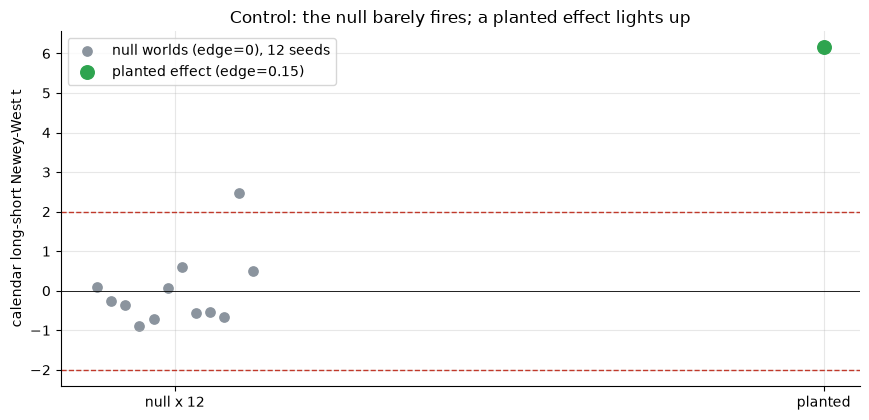

null: mean NW t = -0.02 (sd 0.92), |t|>=2 in 1/12  |  planted NW t = +6.15


In [7]:
null_ts = []
for s_ in range(12):
    p0, e0 = data.synthetic_panel(edge=0.0, seed=858 + s_)
    null_ts.append(st.synthetic_detect(p0, e0)['t_nw'])
null_ts = np.asarray(null_ts)
p1, e1 = data.synthetic_panel(edge=0.15, seed=858)
planted_t = st.synthetic_detect(p1, e1)['t_nw']
fig, ax = plt.subplots(figsize=(8.8, 4.3))
ax.scatter(np.linspace(-.12,.12,12), null_ts, color=GREY, s=45, label='null worlds (edge=0), 12 seeds')
ax.scatter([1], [planted_t], color=GREEN, s=95, zorder=5, label='planted effect (edge=0.15)')
ax.axhline(2, ls='--', c=RED, lw=1); ax.axhline(-2, ls='--', c=RED, lw=1); ax.axhline(0, c='k', lw=.6)
ax.set_xticks([0,1]); ax.set_xticklabels(['null x 12','planted'])
ax.set_ylabel('calendar long-short Newey-West t')
ax.set_title('Control: the null barely fires; a planted effect lights up'); ax.legend()
plt.tight_layout(); plt.show()
print(f'null: mean NW t = {null_ts.mean():+.2f} (sd {null_ts.std(ddof=1):.2f}), '
      f'|t|>=2 in {(abs(null_ts)>=2).sum()}/12  |  planted NW t = {planted_t:+.2f}')

> 💡 In plain words: across 12 null worlds the detector averages NW *t* = -0.02 (sd 0.92) and crosses |t|=2 only 1/12 times — about what chance gives you for a HAC *t* over ~200 months. A planted effect reads NW *t* = 6.15. The machinery is unbiased and powered, so the real-tape -0.18 is a genuine null, not a broken pipeline. *(Power check only — never cited in support of a real-tape stamp.)*

## 5 · The verdict

- **Signal (returns) `NONE`** — calendar tercile long-short -8.1 bps/mo (-1.0%/yr gross), one-sample *t* = -0.20, **Newey-West *t* = -0.18**; staleness-120 flips to +0.09; era split +19→-24 bps; pooled event drift right-signed but flat, non-monotone, placebo-insignificant. Wrong-signed and sign-unstable.
- **Tradability `MIRAGE`** — net of 20 bps + 100 bps borrow: -2.76%/yr, NW *t* = -0.51, Sharpe -0.14; negative before costs.
- **Leads next-year margin? `NO`** — slope -0.000, correlation -0.03, **-0.56 pp** (wrong-signed) top-minus-bottom future-margin spread. The accounting mechanism is absent too.

## 6 · Going further

- **The residual worth chasing** is the *surprise*, not the *level*: inventory or margin moves relative to a seasonal expectation, or the divergence measured inside a single homogeneous industry where 'inventory' means the same thing across names. The fused signal on a mixed retail/manufacturing/staples/hardware basket is the version that fails here.
- **Coverage honesty:** the quarterly-span filter drops fiscal-Q4 figures, six basket names lack usable history, and the cross-section averages ≈17–20 names; but the flat, sign-flipping evidence across ~950 pooled events is decisive for the null.
- **Dedup map:** [529-inventory-growth](../../529-inventory-growth/) (inventory growth level), [854-cash-conversion-cycle](../../854-cash-conversion-cycle/) (working-capital cycle), [122-gross-profitability](../../122-gross-profitability/) (gross profits ÷ assets), [231-sloan-accruals](../../231-sloan-accruals/) (total accruals). None ranks on the margin-vs-inventory-vs-sales divergence itself.

*The reproducible core is offline and deterministic; frozen numbers live in [`docs/results.md`](../docs/results.md), sources in [`docs/references.md`](../docs/references.md).*